# 06 · 非監督式學習：分群與降維

前面都有「答案 `y`」可學。但真實世界常常**沒有標籤**——只有一堆資料，要自己找出結構。這一課用 **KMeans** 自動分群、用 **PCA** 把高維資料壓到 2D 看清楚。

## 學習目標

- 用 `KMeans` 把沒有標籤的資料自動分群
- 用「手肘法」挑選分群數 K
- 用 `PCA` 降維，把高維資料視覺化在平面上
- 理解 `explained_variance_ratio_`（每個主成分保留多少資訊）

## 1. KMeans 分群

KMeans 的目標：把資料分成 K 群，讓每筆資料都靠近自己那群的中心。注意——我們**完全不給它 `y`**，它純粹從特徵的分布找結構。

In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)   # 分群前先標準化
y_true = iris.target                            # 只拿來最後對照，不參與訓練

km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(X)     # 沒有 y！直接給分群標籤

print("分群結果（前 20 筆）:", labels[:20])
print("真實品種（前 20 筆）:", y_true[:20])

分群結果（前 20 筆）: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
真實品種（前 20 筆）: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


> 分群標籤的「編號」是任意的（群 0 不一定對應品種 0），重點是**哪些資料被分到同一群**。

## 2. 該分幾群？手肘法

真實情境你不知道 K 該設多少。**手肘法**：對不同 K 畫出「群內離散程度（inertia）」，曲線從陡降轉平緩的「手肘」處，通常就是好的 K。

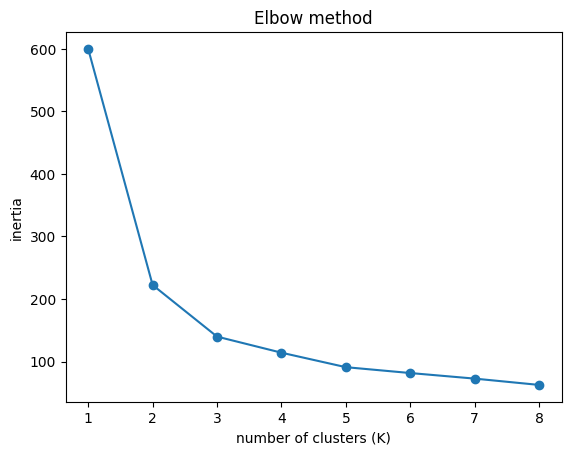

In [2]:
import matplotlib.pyplot as plt

ks = range(1, 9)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in ks]

plt.plot(list(ks), inertias, marker="o")
plt.xlabel("number of clusters (K)")
plt.ylabel("inertia")
plt.title("Elbow method")
plt.show()

## 3. PCA：把 4 維壓到 2 維

鳶尾花有 4 個特徵，畫不出來。**PCA（主成分分析）** 找出資料變異最大的幾個方向，用它們當新座標軸——我們取前 2 個主成分，就能把 4 維資料投影到平面上，而且盡量保留原本的結構。

前 2 個主成分保留的資訊比例: [0.73  0.229]  (合計 95.8%)


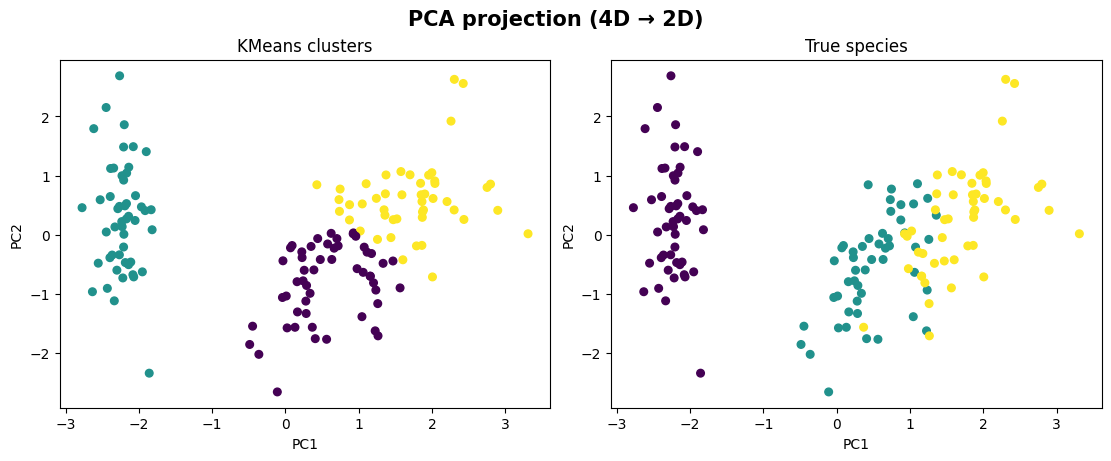

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

ratio = pca.explained_variance_ratio_
print(f"前 2 個主成分保留的資訊比例: {ratio.round(3)}  (合計 {ratio.sum():.1%})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="viridis", s=30)
axes[0].set_title("KMeans clusters")
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="viridis", s=30)
axes[1].set_title("True species")
for ax in axes:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
fig.suptitle("PCA projection (4D → 2D)", fontsize=15, fontweight="bold")
plt.show()

兩張圖長得很像——代表 KMeans 在**完全沒看答案**的情況下，分出來的群幾乎就對應到真實品種。這就是非監督式學習的魅力：從資料本身浮現結構。

> 前 2 個主成分就保留了約 96% 的資訊，所以這張 2D 投影很有代表性。

## 小結

- 非監督式學習不需要標籤 `y`，從特徵分布找結構。
- `KMeans` 自動分群；**手肘法**幫你挑分群數 K。
- `PCA` 降維，把高維資料壓到能視覺化的 2D，`explained_variance_ratio_` 告訴你保留多少資訊。
- 分群標籤的編號是任意的，看的是「分組」而非「對應到哪個答案」。

## 練習

1. 把 KMeans 的 `n_clusters` 改成 2 或 4，PCA 圖上的分群怎麼變？
2. PCA 改成 `n_components=3`，印出三個主成分各自的 `explained_variance_ratio_`。

下一課回到監督式，認識威力強大又好解讀的**樹模型**，並看模型告訴你「哪些特徵最重要」。